# DisasterM3 — QLoRA DDP Fine-Tuning (Dual T4)
**Purpose:** Multi-GPU (DDP) training of Qwen2.5-VL-7B using `accelerate launch` to double throughput.
**Hardware:** Kaggle T4x2 GPUs.

### How to run ("Run All" workflow)
1. **Prerequisites:** Attach Kaggle secrets (`HF_TOKEN`, `KAGGLE_USERNAME`, `KAGGLE_KEY`). Select **GPU T4 x2**. Turn on internet.
2. Set `CKPT_NAME` in the `%%writefile train.py` cell to your latest checkpoint.
3. Click **Run All**.
   - Cell 1 installs dependencies.
   - Cell 2 passes your HF token to the environment.
   - Cell 3 writes the `train.py` script to disk.
   - Cell 4 launches distributed training across both GPUs.

> **Note on output logs:** Because `accelerate launch` spins up sub-processes, the progress bar might not print cleanly in real-time. This is normal. It is working in the background.

In [1]:
# ── Cell 1: Environment Setup (Run-All safe) ──────────────────────────────
# Pin exact versions to avoid Kaggle/torch conflicts.
# This cell is idempotent: if the pinned versions are already installed it
# does nothing and "Run All" proceeds straight into training. If it had to
# install anything, it HALTS the run and asks for a kernel restart — after
# restarting, click "Run All" again and it will skip installation.
import importlib.metadata as _md

PINS = {
    "torch": "2.4.1",
    "torchvision": "0.19.1",
    "torchaudio": "2.4.1",       # MUST match torch — unpinned torchaudio causes an ABI crash
    "transformers": "4.49.0",    # 4.46.x is too old for Qwen2_5_VLForConditionalGeneration
    "peft": "0.14.0",
    "bitsandbytes": "0.45.0",
    "accelerate": "1.2.1",
    "trl": "0.13.0",
    "qwen-vl-utils": "0.0.8",
}

_mismatched = []
for _pkg, _want in PINS.items():
    try:
        _have = _md.version(_pkg)
    except _md.PackageNotFoundError:
        _have = "not installed"
    if _have != _want:
        _mismatched.append(f"{_pkg}: {_have} → {_want}")

if _mismatched:
    print("⏳ Installing pinned versions:")
    for _m in _mismatched:
        print(f"   {_m}")
    !pip install -q \
        torch==2.4.1 \
        torchvision==0.19.1 \
        torchaudio==2.4.1 \
        transformers==4.49.0 \
        peft==0.14.0 \
        bitsandbytes==0.45.0 \
        accelerate==1.2.1 \
        trl==0.13.0 \
        qwen-vl-utils==0.0.8 \
        pillow \
        huggingface_hub[hf_xet]
    # Halt "Run All" here — imports must not happen before a kernel restart.
    raise SystemExit(
        "✓ Dependencies installed. RESTART THE KERNEL NOW "
        "(Run → Restart & clear cell outputs), then click 'Run All' again — "
        "this cell will detect the correct versions and skip installation."
    )

print("✓ All pinned versions already installed — proceeding.")

✓ All pinned versions already installed — proceeding.


In [2]:
import os
from kaggle_secrets import UserSecretsClient

try:
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("✓ Exported HF_TOKEN for subprocesses.")
except Exception as e:
    print(f"⚠ Could not export HF_TOKEN (are secrets attached?): {e}")

✓ Exported HF_TOKEN for subprocesses.


In [ ]:
%%writefile train.py
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import json
import torch
import shutil
import glob
import time
from pathlib import Path
from datetime import datetime

# --- DDP Setup (Custom for T4x2) ---
local_rank = int(os.environ.get("LOCAL_RANK", "0"))
device_map = {"": local_rank}
torch.cuda.set_device(local_rank)

def is_main_process():
    return local_rank == 0

def log(msg):
    if is_main_process():
        print(msg)

log(f"✓ Starting DDP Training Script. Using GPU {local_rank} on this process.\n")
# -----------------------------------

# ── Cell 2: Configuration ─────────────────────────────────────────────────
# ── Paths ──
# Using the exact path you found!
DATA_ROOT = Path("/kaggle/input/datasets/abrarmohammedtanzim/disasterm3-instruct-mirror/DisasterM3_Instruct")
log(f"✓ Using Kaggle Dataset mount: {DATA_ROOT}")

MANIFEST_PATH = DATA_ROOT / "train_release.json"
IMAGE_DIR = Path("/tmp/train_images")  # Will unzip here
BOX_IMAGE_DIR = Path("/tmp/box_train_images")
MASK_DIR = Path("/tmp/masks")

# ── Model ──
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

# ── LoRA config (Appendix B.3) ──
LORA_RANK = 64
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

# ── Training config ──
LEARNING_RATE = 2e-4
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.95
NUM_EPOCHS = 1
PER_DEVICE_BATCH = 1              # T4 constraint
GRADIENT_ACCUMULATION = 128       # DDP MODIFICATION: 2 GPUs × 128 = 256 global batch
MAX_SEQ_LENGTH = 1536             # Qwen2.5-VL default
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01

# ── Image token budget (T4 constraint — log in DEVIATIONS.md) ──
# Caps Qwen2.5-VL's dynamic resolution so a pre/post image pair (~2×512 tokens)
# always fits in MAX_SEQ_LENGTH without truncating image placeholder tokens.
# Also the single biggest throughput lever on a T4 (2-4× faster).
MIN_PIXELS = 256 * 28 * 28        # ≥ ~256 vision tokens per image
MAX_PIXELS = 400 * 28 * 28        # ≤ ~512 vision tokens per image

# ── Checkpointing (12-hour Kaggle session cap) ──
# SAVE_STEPS=2 optimizer steps × 256 grad-accum = 512 samples ≈ 25-50 min on T4.
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
SAVE_STEPS = 2
LOGGING_STEPS = 1                 # 1 optimizer step = 256 samples; log every step
TIME_LIMIT_HOURS = 11           # Save + stop cleanly before Kaggle's 12 h wall

# ── Cross-session resume ──
RESUME_CHECKPOINT_DATASET = None
HF_REPO = "AbrarAlam/disasterm3-qwen25vl7b-qlora"

# ----- UPDATE THIS FOR EACH SESSION -----
CKPT_NAME = "checkpoint-55"
# --------------------------------------

# ── Output ──
OUTPUT_DIR = "/kaggle/working/qwen25vl_disasterm3_qlora"
ADAPTER_NAME = f"disasterm3_qwen25vl7b_qlora_r{LORA_RANK}_a{LORA_ALPHA}"

log(f"✓ Config loaded")
log(f"  Model: {MODEL_ID}")
log(f"  LoRA: rank={LORA_RANK}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
log(f"  Effective batch size: {PER_DEVICE_BATCH} × {GRADIENT_ACCUMULATION} × 2 GPUs = {PER_DEVICE_BATCH * GRADIENT_ACCUMULATION * 2}\n")

# ── Cell 4: Load manifest and build chat dataset ─────────────────────────
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

log(f"Loaded {len(raw_data):,} entries from manifest")

# ── Audit: segmentation training_answer (plan addendum item 6) ────────────
# For Referring Expression Segmentation, ground_truth is a MASK FILE PATH.
# If training_answer were empty and we fell back to ground_truth, we would be
# training the model to emit path strings for 40% of the data. Audit first.
PATH_SUFFIXES = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

def _answer_text(entry):
    ans = entry.get("training_answer", "")
    if isinstance(ans, list):
        ans = ans[0] if ans else ""
    return str(ans).strip()

seg_entries = [e for e in raw_data if e.get("task") == "Referring Expression Segmentation"]
seg_empty = sum(1 for e in seg_entries if not _answer_text(e))
seg_pathlike = sum(1 for e in seg_entries if _answer_text(e).lower().endswith(PATH_SUFFIXES))
log(f"\nSegmentation audit: {len(seg_entries):,} entries | "
      f"empty training_answer: {seg_empty:,} | path-like: {seg_pathlike:,}")
if seg_entries:
    ex = seg_entries[0]
    log(f"  sample training_answer: {_answer_text(ex)[:150]!r}")
    log(f"  sample ground_truth:    {str(ex.get('ground_truth', ''))[:150]!r}")

def resolve_image_path(rel_path):
    """Resolve a manifest-relative path to an absolute path on disk."""
    if not rel_path: return None
    rel_path = rel_path.replace("\\", "/")
    filename = Path(rel_path).name
    candidates = [
        DATA_ROOT / rel_path,
        DATA_ROOT / "train_images" / rel_path,
        DATA_ROOT / "box_train_images" / rel_path,
        DATA_ROOT / "masks" / rel_path,
        DATA_ROOT / "train_images" / "train_images" / filename,
        DATA_ROOT / "box_train_images" / "box_train_images" / filename,
        DATA_ROOT / "masks" / "masks" / filename,
        Path("/tmp") / rel_path
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return None

def entry_to_messages(entry):
    """Convert a manifest entry to Qwen2.5-VL chat messages format."""
    task = entry.get("task", "")
    user_content = []
    
    if "image_path" in entry:
        # Relational reasoning: single post-disaster image with bounding boxes
        img_path = resolve_image_path(entry["image_path"])
        if img_path: user_content.append({"type": "image", "image": f"file://{img_path}"})
    else:
        # All other tasks: pre + post disaster pair
        pre_path = resolve_image_path(entry.get("pre_image_path", ""))
        post_path = resolve_image_path(entry.get("post_image_path", ""))
        if pre_path: user_content.append({"type": "image", "image": f"file://{pre_path}"})
        if post_path: user_content.append({"type": "image", "image": f"file://{post_path}"})
        
    # Skip entries where images couldn't be resolved
    if not any(c.get("type") == "image" for c in user_content): return None
    
    # Add prompt text
    prompt = entry.get("prompts", "")
    if isinstance(prompt, list): prompt = prompt[0]
    user_content.append({"type": "text", "text": prompt})
    
    # Get the training answer.
    # NO ground_truth fallback: for segmentation entries ground_truth is a mask
    # file path — training on it would teach the model to emit path strings.
    answer = _answer_text(entry)
    if not answer or answer.lower().endswith(PATH_SUFFIXES): return None
    
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]}
    ]
    return messages

log("\nConverting manifest entries to chat format...")
chat_dataset = []
from collections import Counter
task_counts = Counter()
skip_counts = Counter()

for entry in raw_data:
    msgs = entry_to_messages(entry)
    task = entry.get("task", "unknown")
    if msgs is not None:
        chat_dataset.append({"messages": msgs, "task": task})
        task_counts[task] += 1
    else:
        skip_counts[task] += 1

log(f"\n✓ Converted: {len(chat_dataset):,} entries")
log(f"  Skipped (missing images or unusable answer): {sum(skip_counts.values()):,}")
if skip_counts:
    log(f"\n  Skips per task (record in DEVIATIONS.md):")
    for task, count in skip_counts.most_common():
        log(f"    {task:<45} {count:>6,}")
log(f"\nPer-task breakdown (kept):")
for task, count in task_counts.most_common():
    log(f"  {task:<45} {count:>6,}")
log("\n")

# ── Cell 5: Load Qwen2.5-VL-7B with 4-bit quantization ───────────────────
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# 4-bit quantization config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,  # fp16 (T4 has no native bf16)
    bnb_4bit_use_double_quant=True,
)

log(f"⏳ Loading {MODEL_ID} in 4-bit...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=device_map,               # DDP MODIFICATION
    attn_implementation="sdpa",          # T4 can't use flash_attention_2
    torch_dtype=torch.float16,
)

# Pixel budget bounds vision tokens (~256-512 per image) so a pre/post pair
# plus prompt+answer fits in MAX_SEQ_LENGTH without cutting image tokens.
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

# Prepare for k-bit training
model = prepare_model_for_kbit_training(model)

log(f"✓ Model loaded")
# In DDP, parameters calculation might be redundant to print on all processes, just print on main
if is_main_process():
    log(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    log(f"  Trainable before LoRA: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

# ── Cell 6: Apply LoRA adapters ───────────────────────────────────────────
# Target: LLM component ONLY (vision encoder frozen) — matches paper's recipe.
# IMPORTANT: a plain name list like ["gate_proj", ...] ALSO matches the vision
# tower's MLP layers (Qwen2.5-VL's ViT blocks use the same gate/up/down_proj
# names), silently adding ~29M trainable params inside the "frozen" vision
# encoder. The regex below anchors matching to the language model's layers.

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    # str target_modules is treated as a regex (full match on module path):
    # matches model.layers.N.self_attn.{q,k,v,o}_proj and
    #         model.layers.N.mlp.{gate,up,down}_proj — never visual.blocks.*
    target_modules=(
        r"^model\.layers\.\d+\."
        r"(self_attn\.(q_proj|k_proj|v_proj|o_proj)"
        r"|mlp\.(gate_proj|up_proj|down_proj))$"
    ),
    task_type="CAUSAL_LM",
    bias="none",
)

model = get_peft_model(model, lora_config)

# Guard: fail loudly if any LoRA module ended up in the vision tower.
_lora_on_vision = [
    n for n, _ in model.named_modules()
    if "visual" in n and "lora_" in n
]
assert not _lora_on_vision, (
    f"LoRA attached to vision tower (violates frozen-vision recipe): "
    f"{_lora_on_vision[:5]}"
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
log(f"✓ LoRA adapters applied (LLM only — vision tower verified LoRA-free)")
log(f"  Trainable parameters: {trainable:,} ({trainable/total*100:.2f}%)")
log(f"  Expected (28 LLM layers, r=64): 161,480,704")
log(f"  Total parameters:     {total:,}\n")

# ── Cell 7: Set up SFTTrainer ─────────────────────────────────────────────
from trl import SFTTrainer, SFTConfig
import torch.utils.data

# Keep examples as plain Python dicts. Do NOT use datasets.Dataset.from_list():
# Arrow unifies the schema of the nested content items and injects `image: None`
# into text items, which crashes process_vision_info on the first batch
# (the AttributeError observed in the first training attempt).
class ChatListDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = ChatListDataset(chat_dataset)

# SFT training config
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    adam_beta1=ADAM_BETA1,
    adam_beta2=ADAM_BETA2,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    max_seq_length=MAX_SEQ_LENGTH,
    fp16=True,                         # T4: fp16 only
    bf16=False,                        # T4: no native bf16
    gradient_checkpointing=True,       # Save VRAM
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=3,                # Keep last 3 checkpoints
    report_to="none",                  # No wandb on Kaggle
    dataloader_num_workers=2,
    remove_unused_columns=False,
    max_grad_norm=1.0,                 # Gradient clipping (important for fp16)
    dataset_text_field=None,           # We use messages format
    dataset_kwargs={"skip_prepare_dataset": True},
    ddp_find_unused_parameters=False,  # DDP MODIFICATION: highly recommended for efficiency
)

log("✓ Training config ready")
log(f"  Steps per epoch: ~{len(chat_dataset) // (PER_DEVICE_BATCH * GRADIENT_ACCUMULATION * 2)}")
log(f"  Total optimizer steps: ~{len(chat_dataset) // (PER_DEVICE_BATCH * GRADIENT_ACCUMULATION * 2) * NUM_EPOCHS}\n")

# ── Cell 8: Custom data collator for Qwen2.5-VL ──────────────────────────
from qwen_vl_utils import process_vision_info

# Token ids used for label masking
IMAGE_PAD_ID = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
VISION_START_ID = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
VISION_END_ID = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
# "<|im_start|>assistant\n" marks where the response begins in Qwen's template
ASSISTANT_MARKER_IDS = processor.tokenizer(
    "<|im_start|>assistant\n", add_special_tokens=False
)["input_ids"]

def _strip_none(content):
    """Drop None-valued keys from content items (defensive vs Arrow-style
    schema padding, which crashes process_vision_info)."""
    return [{k: v for k, v in item.items() if v is not None} for item in content]

def _mask_prompt_tokens(labels_row):
    """Mask everything up to and including the last assistant marker, so loss
    covers only the assistant response (standard SFT-on-responses)."""
    ids = labels_row.tolist()
    m = ASSISTANT_MARKER_IDS
    for start in range(len(ids) - len(m), -1, -1):
        if ids[start:start + len(m)] == m:
            labels_row[: start + len(m)] = -100
            return True
    return False

def collate_fn(examples):
    """Collator for Qwen2.5-VL multi-image inputs with assistant-only loss."""
    texts = []
    all_images = []  # flat list, in example order — the processor matches
                     # images to <image> placeholders in order across the batch

    for example in examples:
        messages = [
            {"role": msg["role"], "content": _strip_none(msg["content"])}
            for msg in example["messages"]
        ]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)

        image_inputs, _ = process_vision_info(messages)
        if image_inputs:
            all_images.extend(image_inputs)

    # Truncation is safe now: image tokens sit at the START of the sequence and
    # the processor's max_pixels cap bounds them (~1024 for a pre/post pair),
    # so truncation can only ever trim answer text, never image placeholders.
    batch = processor(
        text=texts,
        images=all_images if all_images else None,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    # Never compute LM loss on vision positions
    labels[labels == IMAGE_PAD_ID] = -100
    labels[labels == VISION_START_ID] = -100
    labels[labels == VISION_END_ID] = -100
    # Assistant-only loss: mask the system/user turn in every row
    for row in labels:
        _mask_prompt_tokens(row)
    batch["labels"] = labels

    if torch.cuda.memory_reserved() > 14 * 1024**3: torch.cuda.empty_cache()
    return batch

log("✓ Custom collator defined (assistant-only loss, image tokens masked)\n")


# ── Cell 8.5: Restore latest checkpoint from HF (run before Cell 9) ───────────────
from huggingface_hub import snapshot_download

# Only main process should download to avoid race conditions
if is_main_process() and CKPT_NAME:
    hf_token = os.environ.get("HF_TOKEN")
    local = snapshot_download(
        repo_id=HF_REPO,
        repo_type="model",
        token=hf_token,
        allow_patterns=f"checkpoints/{CKPT_NAME}/**",
    )
    src = os.path.join(local, "checkpoints", CKPT_NAME)
    dst = os.path.join(OUTPUT_DIR, CKPT_NAME)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    log(f"✓ Restored {CKPT_NAME} → {dst}\n")

# Barrier to ensure main process finishes download before others proceed
if torch.distributed.is_initialized():
    torch.distributed.barrier()

# ── Cell 9: Resume from checkpoint if available ─────────────────────────
# (Note: Kaggle Dataset resume block omitted in DDP since we use HF entirely)
resume_from = None
if os.path.exists(OUTPUT_DIR):
    checkpoints = [
        d for d in os.listdir(OUTPUT_DIR)
        if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
    ]
    if checkpoints:
        latest = max(checkpoints, key=lambda x: int(x.split("-")[1]))
        resume_from = os.path.join(OUTPUT_DIR, latest)
        log(f"✓ Resuming from checkpoint: {resume_from}")
    else:
        log("No existing checkpoints found — starting fresh")
else:
    log("No output directory found — starting fresh")

# ── Cell 10: Train! ───────────────────────────────────────────────────────
from transformers import TrainerCallback

class TimeLimitCallback(TrainerCallback):
    """Write a final checkpoint and stop cleanly before Kaggle's 12 h wall,
    leaving time to persist it instead of being killed mid-step."""
    def __init__(self, max_hours):
        self.deadline = time.time() + max_hours * 3600
    def on_step_end(self, args, state, control, **kwargs):
        if time.time() > self.deadline:
            log(f"⏰ Time budget reached at optimizer step {state.global_step} "
                  f"— saving checkpoint and stopping.")
            control.should_save = True
            control.should_training_stop = True
        return control

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
    callbacks=[TimeLimitCallback(TIME_LIMIT_HOURS)],
)

log(f"\n⏳ Starting training at {datetime.now().strftime('%H:%M:%S')}...")
log(f"   This will take several hours on a T4x2.")
log(f"   Checkpoints saved every {SAVE_STEPS} steps to {OUTPUT_DIR}\n")

trainer.train(resume_from_checkpoint=resume_from)

log(f"\n✓ Training complete at {datetime.now().strftime('%H:%M:%S')}")

# --- BACKUP FINAL CHECKPOINT (Main Process Only) ---
if is_main_process():
    from huggingface_hub import HfApi
    api = HfApi(token=os.environ.get("HF_TOKEN"))
    ckpts = sorted(glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-*")), key=lambda p: int(p.split("-")[-1]))
    if ckpts:
        latest_ckpt = ckpts[-1]
        ckpt_folder = os.path.basename(latest_ckpt)
        log(f"\n⏳ Pushing {ckpt_folder} to HF Hub...")
        api.upload_folder(
            folder_path=latest_ckpt,
            path_in_repo=f"checkpoints/{ckpt_folder}",
            repo_id=HF_REPO,
            repo_type="model"
        )
        log("✓ Push complete!")


Writing train.py


In [4]:
# Launch the training script across 2 GPUs
!accelerate launch --multi_gpu --num_processes=2 train.py

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
✓ Starting DDP Training Script. Using GPU 0 on this process.

✓ Using Kaggle Dataset mount: /kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct
✓ Config loaded
  Model: Qwen/Qwen2.5-VL-7B-Instruct
  LoRA: rank=64, alpha=16, dropout=0.05
  Effective batch size: 1 × 128 × 2 GPUs = 256

Loaded 92,968 entries from manifest

Segmentation audit: 37,204 entries | empty training_answer: 37,204 | path-like: 0
  sample training_answer: ''
  sample ground_truth:    'masks\\flooding_mask\\hurricane_florence_00000029.png'

Converting manifest entries to chat format...

✓ Converted: 55,764 entries
  Skipped (missing images or unusable answ

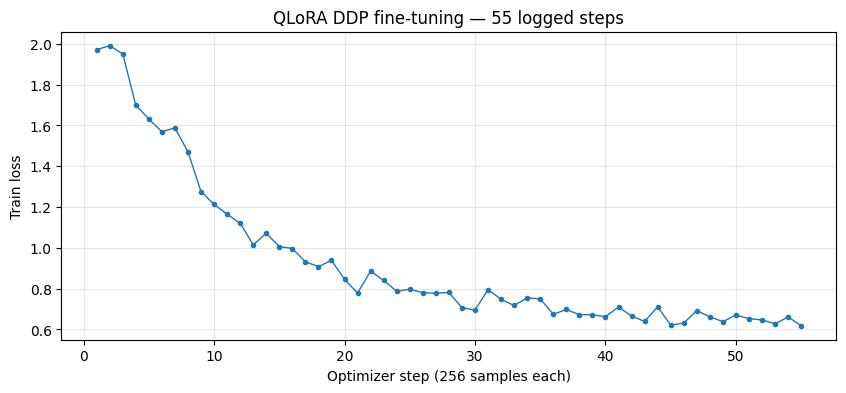

✓ Curve saved to /kaggle/working/qwen25vl_disasterm3_qlora/loss_curve.png
  Last 5 losses: [0.6526, 0.6464, 0.6272, 0.661, 0.618]


In [5]:
# ── Cell 6: Train-loss curve (full run across all sessions) ──────────────
# trainer.state.log_history is persisted inside every checkpoint as
# trainer_state.json and SURVIVES resume — so this plot always shows the
# whole multi-session curve.
import glob
import json
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "/kaggle/working/qwen25vl_disasterm3_qlora"

log_history = None
_ckpts = sorted(
    glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-*")),
    key=lambda p: int(p.split("-")[-1]),
)
if _ckpts:
    try:
        with open(os.path.join(_ckpts[-1], "trainer_state.json")) as f:
            log_history = json.load(f).get("log_history", [])
    except Exception as e:
        print(f"Could not load log history: {e}")

if not log_history:
    print("No training logs found.")
else:
    steps = [e["step"] for e in log_history if "loss" in e]
    losses = [e["loss"] for e in log_history if "loss" in e]
    if not steps:
        print("Log history contains no loss entries yet.")
    else:
        plt.figure(figsize=(10, 4))
        plt.plot(steps, losses, marker="o", markersize=3, linewidth=1)
        plt.xlabel("Optimizer step (256 samples each)")
        plt.ylabel("Train loss")
        plt.title(f"QLoRA DDP fine-tuning — {len(steps)} logged steps")
        plt.grid(alpha=0.3)
        curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
        plt.savefig(curve_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"✓ Curve saved to {curve_path}")
        print(f"  Last 5 losses: {[round(l, 4) for l in losses[-5:]]}")
        if any(l != l for l in losses):
            print("⚠ NaN detected in loss history — stop and investigate!")

In [6]:
# ── Cell 7: Format and Save Final Adapter ──────────────────────────────
# In DDP, the model only existed in the subprocesses. But the subprocesses
# cleanly saved the checkpoints to disk. A Hugging Face checkpoint IS an adapter!
import os, glob, shutil, json
from datetime import datetime

OUTPUT_DIR = "/kaggle/working/qwen25vl_disasterm3_qlora"
LORA_RANK = 64
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1
PER_DEVICE_BATCH = 1
GRADIENT_ACCUMULATION = 128
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

ADAPTER_NAME = f"disasterm3_qwen25vl7b_qlora_r{LORA_RANK}_a{LORA_ALPHA}"
adapter_path = os.path.join(OUTPUT_DIR, ADAPTER_NAME)

_ckpts = sorted(
    glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-*")),
    key=lambda p: int(p.split("-")[-1]),
)

if _ckpts:
    latest_ckpt = _ckpts[-1]
    if not os.path.exists(adapter_path):
        # Copy the checkpoint folder
        shutil.copytree(latest_ckpt, adapter_path)
        
    # Bundle loss curve
    curve_src = os.path.join(OUTPUT_DIR, "loss_curve.png")
    if os.path.exists(curve_src):
        shutil.copy2(curve_src, os.path.join(adapter_path, "loss_curve.png"))
        print("✓ Bundled loss_curve.png into adapter folder")

    # Bundle trainer_state.json
    state_src = os.path.join(latest_ckpt, "trainer_state.json")
    if os.path.exists(state_src):
        shutil.copy2(state_src, os.path.join(adapter_path, "trainer_state.json"))
        print(f"✓ Bundled trainer_state.json (from {os.path.basename(latest_ckpt)}) into adapter folder")
        
    # Write full summary
    summary = {
        "model": "Qwen/Qwen2.5-VL-7B-Instruct",
        "adapter_name": ADAPTER_NAME,
        "lora_rank": LORA_RANK,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "learning_rate": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "per_device_batch": PER_DEVICE_BATCH,
        "gradient_accumulation": GRADIENT_ACCUMULATION,
        "effective_batch_size": PER_DEVICE_BATCH * GRADIENT_ACCUMULATION * 2,
        "precision": "fp16 + NF4 QLoRA",
        "attention": "sdpa",
        "min_pixels": MIN_PIXELS,
        "max_pixels": MAX_PIXELS,
        "loss_target": "assistant response only (prompt/image tokens masked)",
        "training_type": "DDP Dual-T4",
        "timestamp": datetime.now().isoformat(),
    }
    with open(os.path.join(adapter_path, "training_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
        
    print(f"\n✓ Standalone adapter formatted and saved to: {adapter_path}")
    print(f"  Contents:")
    for f in sorted(os.listdir(adapter_path)):
        size = os.path.getsize(os.path.join(adapter_path, f)) / 1e6
        print(f"    {f:<40} {size:.1f} MB")

    # Push standalone adapter to HF Hub
    try:
        from kaggle_secrets import UserSecretsClient
        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
        from huggingface_hub import HfApi
        api = HfApi(token=hf_token)
        hf_user = api.whoami()["name"]
        hf_repo = f"{hf_user}/disasterm3-qwen25vl7b-qlora"
        api.create_repo(hf_repo, private=True, exist_ok=True)
        api.upload_folder(
            folder_path=adapter_path,
            repo_id=hf_repo,
            path_in_repo=ADAPTER_NAME,
            commit_message=f"adapter snapshot @ {datetime.now().isoformat()} (DDP)",
        )
        print(f"✓ Adapter pushed to HF Hub: {hf_repo}/{ADAPTER_NAME}")
    except Exception as e:
        print(f"ℹ HF Hub adapter push skipped ({e}).")
else:
    print("No checkpoints found. Train first.")


✓ Bundled loss_curve.png into adapter folder
✓ Bundled trainer_state.json (from checkpoint-55) into adapter folder

✓ Standalone adapter formatted and saved to: /kaggle/working/qwen25vl_disasterm3_qlora/disasterm3_qwen25vl7b_qlora_r64_a16
  Contents:
    README.md                                0.0 MB
    adapter_config.json                      0.0 MB
    adapter_model.safetensors                646.0 MB
    added_tokens.json                        0.0 MB
    dataset-metadata.json                    0.0 MB
    loss_curve.png                           0.0 MB
    merges.txt                               1.7 MB
    optimizer.pt                             1292.2 MB
    rng_state.pth                            0.0 MB
    scaler.pt                                0.0 MB
    scheduler.pt                             0.0 MB
    special_tokens_map.json                  0.0 MB
    tokenizer.json                           11.4 MB
    tokenizer_config.json                    0.0 MB
    trainer_sta

KeyboardInterrupt: 

In [ ]:
# ── Cell 8: Sanity check inference ────────────────────────────────────────
# Because `accelerate launch` clears the GPUs when it finishes, we can load
# a fresh 4-bit model into the notebook kernel, attach the adapter we just
# saved, and test it! (This perfectly simulates how evaluation will work).
import torch, os, json, random
from pathlib import Path
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel
from qwen_vl_utils import process_vision_info

LORA_RANK = 64
LORA_ALPHA = 16
ADAPTER_NAME = f"disasterm3_qwen25vl7b_qlora_r{LORA_RANK}_a{LORA_ALPHA}"
adapter_path = os.path.join("/kaggle/working/qwen25vl_disasterm3_qlora", ADAPTER_NAME)

DATA_ROOT = Path("/kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct")

def resolve_image_path(rel_path):
    if not rel_path: return None
    rel_path = rel_path.replace("\\", "/")
    filename = Path(rel_path).name
    candidates = [
        DATA_ROOT / rel_path,
        DATA_ROOT / "train_images" / rel_path,
        DATA_ROOT / "box_train_images" / rel_path,
        DATA_ROOT / "masks" / rel_path,
        DATA_ROOT / "train_images" / "train_images" / filename,
        DATA_ROOT / "box_train_images" / "box_train_images" / filename,
        DATA_ROOT / "masks" / "masks" / filename,
        Path("/tmp") / rel_path
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return None

if os.path.exists(adapter_path):
    print(f"⏳ Loading fresh base model and attaching adapter...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    
    base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2.5-VL-7B-Instruct",
        quantization_config=bnb_config,
        device_map="auto",
    )
    processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
    
    model = PeftModel.from_pretrained(base_model, adapter_path)
    
    manifest = DATA_ROOT / "train_release.json"
    with open(manifest) as f:
        data = json.load(f)
        
    PATH_SUFFIXES = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    valid_entries = []
    
    # Grab a random valid entry (mimics entry_to_messages from train.py)
    while not valid_entries:
        test_entry = random.choice(data)
        
        user_content = []
        if "image_path" in test_entry:
            img_path = resolve_image_path(test_entry["image_path"])
            if img_path: user_content.append({"type": "image", "image": f"file://{img_path}"})
        else:
            pre_path = resolve_image_path(test_entry.get("pre_image_path", ""))
            post_path = resolve_image_path(test_entry.get("post_image_path", ""))
            if pre_path: user_content.append({"type": "image", "image": f"file://{pre_path}"})
            if post_path: user_content.append({"type": "image", "image": f"file://{post_path}"})
            
        if not any(c.get("type") == "image" for c in user_content): continue
        
        prompt = test_entry.get("prompts", "")
        if isinstance(prompt, list): prompt = prompt[0]
        user_content.append({"type": "text", "text": prompt})
        
        ans = test_entry.get("training_answer", "")
        if isinstance(ans, list): ans = ans[0] if ans else ""
        if not ans or str(ans).strip().lower().endswith(PATH_SUFFIXES): continue
        
        messages = [
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": [{"type": "text", "text": str(ans).strip()}]}
        ]
        valid_entries.append((test_entry, messages))
        
    entry, msgs = valid_entries[0]
    
    # Only keep user message for generation
    user_msg = [msgs[0]]
    
    text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(user_msg)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
    ).to(model.device)
    
    print("⏳ Generating response...")
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=256, do_sample=False)
        
    output_text = processor.batch_decode(
        generated[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]
    
    print(f"\nTask: {entry.get('task')}")
    expected = msgs[1]['content'][0]['text']
    print(f"Expected: {expected[:200]}...")
    print(f"\nGenerated: {output_text[:200]}...")
    print(f"\n✓ Sanity check passed — model successfully generated text from the adapter!")
else:
    print("Adapter not found. Cannot run sanity check.")
